In [4]:
import pandas as pd

train = pd.read_csv("train (1).csv")
test = pd.read_csv("test.csv")

print(train.head())
print(train.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [5]:
# Fill missing values

train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())

train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

test["Fare"] = test["Fare"].fillna(test["Fare"].median())

# Convert text columns into numeric values

train["Sex"] = train["Sex"].map({"male": 0, "female": 1})
test["Sex"] = test["Sex"].map({"male": 0, "female": 1})

train["Embarked"] = train["Embarked"].map({"S": 0, "C": 1, "Q": 2})
test["Embarked"] = test["Embarked"].map({"S": 0, "C": 1, "Q": 2})

print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin  Embarked  
0         A/5 21171   7.2500   NaN         0  
1          PC 17599  71.2833   C85         1  
2  STON/O2. 3101282   7.9250   NaN         0  
3            113803  53.1000  C123         0  
4            373450   8.0500   NaN         0  


In [6]:
# Select important features

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = train[features]

y = train["Survived"]

X_test = test[features]

print(X.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    0  22.0      1      0   7.2500         0
1       1    1  38.0      1      0  71.2833         1
2       3    1  26.0      0      0   7.9250         0
3       1    1  35.0      1      0  53.1000         0
4       3    0  35.0      0      0   8.0500         0


In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data into training and validation sets

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model on training data

model.fit(X_train, y_train)

# Predict on validation data

predictions = model.predict(X_valid)

# Calculate accuracy

accuracy = accuracy_score(y_valid, predictions)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8044692737430168


In [10]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

    Feature  Importance
1       Sex    0.419950
5      Fare    0.187297
2       Age    0.143817
0    Pclass    0.131502
3     SibSp    0.050160
4     Parch    0.035817
6  Embarked    0.031457


In [11]:
# Create FamilySize feature

train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

# Create IsAlone feature

train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

print(train[["FamilySize", "IsAlone"]].head())

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


In [12]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = train[features]
y = train["Survived"]

X_test = test[features]

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create improved model

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

# Train model

model.fit(X_train, y_train)

# Validate

predictions = model.predict(X_valid)

accuracy = accuracy_score(y_valid, predictions)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8212290502793296


In [14]:
# Extract titles from passenger names

train["Title"] = train["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)
test["Title"] = test["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)

print(train["Title"].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64


<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
C:\Users\aarya\AppData\Local\Temp\ipykernel_25348\1709836606.py:3: SyntaxWarning: invalid escape sequence '\.'
  train["Title"] = train["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\aarya\AppData\Local\Temp\ipykernel_25348\1709836606.py:4: SyntaxWarning: invalid escape sequence '\.'
  test["Title"] = test["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)


In [15]:
# Replace rare titles

rare_titles = [
    "Lady", "Countess", "Capt", "Col",
    "Don", "Dr", "Major", "Rev",
    "Sir", "Jonkheer", "Dona"
]

train["Title"] = train["Title"].replace(rare_titles, "Rare")
test["Title"] = test["Title"].replace(rare_titles, "Rare")

# Standardize titles

train["Title"] = train["Title"].replace("Mlle", "Miss")
train["Title"] = train["Title"].replace("Ms", "Miss")
train["Title"] = train["Title"].replace("Mme", "Mrs")

test["Title"] = test["Title"].replace("Mlle", "Miss")
test["Title"] = test["Title"].replace("Ms", "Miss")
test["Title"] = test["Title"].replace("Mme", "Mrs")

print(train["Title"].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [16]:
title_mapping = {
    "Mr": 1,
    "Miss": 2,
    "Mrs": 3,
    "Master": 4,
    "Rare": 5
}

train["Title"] = train["Title"].map(title_mapping)
test["Title"] = test["Title"].map(title_mapping)

# Fill missing values if any

train["Title"] = train["Title"].fillna(0)
test["Title"] = test["Title"].fillna(0)

print(train["Title"].head())

0    1
1    3
2    2
3    3
4    1
Name: Title, dtype: int64


In [17]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]

X = train[features]
y = train["Survived"]

X_test = test[features]

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Stronger Random Forest

model = RandomForestClassifier(
    n_estimators=700,
    max_depth=9,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

# Train

model.fit(X_train, y_train)

# Predict

predictions = model.predict(X_valid)

# Accuracy

accuracy = accuracy_score(y_valid, predictions)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8435754189944135


In [19]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.83240223 0.79775281 0.87078652 0.81460674 0.83707865]
Average CV Accuracy: 0.830525390747599


In [20]:
# Train model on full dataset

model.fit(X, y)

# Predict on test dataset

final_predictions = model.predict(X_test)

# Create submission dataframe

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_predictions
})

# Save CSV

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Create XGBoost model

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model

xgb_model.fit(X_train, y_train)

# Predict

xgb_predictions = xgb_model.predict(X_valid)

# Accuracy

xgb_accuracy = accuracy_score(y_valid, xgb_predictions)

print("XGBoost Validation Accuracy:", xgb_accuracy)

XGBoost Validation Accuracy: 0.8491620111731844


In [23]:
from sklearn.model_selection import cross_val_score

xgb_cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("XGBoost CV Scores:", xgb_cv_scores)
print("Average XGBoost CV Accuracy:", xgb_cv_scores.mean())

XGBoost CV Scores: [0.83240223 0.82022472 0.89325843 0.8258427  0.83146067]
Average XGBoost CV Accuracy: 0.8406377502981608


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, xgb_predictions)

print(cm)

[[93 12]
 [15 59]]


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, xgb_predictions)

print(cm)

[[93 12]
 [15 59]]


In [26]:
from sklearn.metrics import classification_report

report = classification_report(
    y_valid,
    xgb_predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.86      0.89      0.87       105
           1       0.83      0.80      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



      Feature  Importance
7       Title    0.317719
1         Sex    0.259642
0      Pclass    0.145293
5  FamilySize    0.070172
3        Fare    0.062360
4    Embarked    0.050901
2         Age    0.048151
6     IsAlone    0.045762


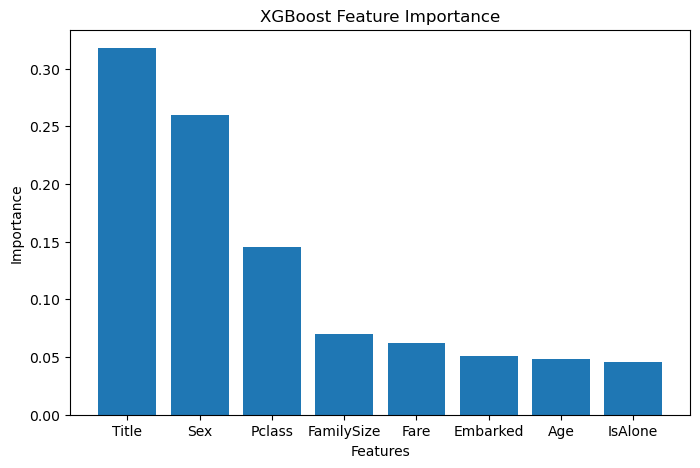

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Parameter grid

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.8, 1.0]
}

# Base model

xgb = XGBClassifier(
    random_state=42
)

# Grid Search

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

# Train

grid_search.fit(X, y)

# Best parameters

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Accuracy:")
print(grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters:
{'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Accuracy:
0.8484848484848485


In [31]:
# Conservative XGBoost model

final_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train

final_xgb.fit(X, y)

# Predict

final_predictions = final_xgb.predict(X_test)

# Create submission

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_predictions
})

# Save CSV

submission.to_csv("improved_submission.csv", index=False)

print("improved_submission.csv created!")

improved_submission.csv created!


In [30]:
# Create final submission dataframe

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_predictions
})

# Save CSV

submission.to_csv("final_submission.csv", index=False)

print("final_submission.csv created successfully!")

final_submission.csv created successfully!
